# 06 - Interpretability: SHAP on the CNN-LSTM, vs. the internship's SHAP findings

The internship used SHAP on its final Ridge (DBT) and LightGBM (WBT) models. This
notebook applies SHAP to the CNN-LSTM hybrid's flattened input (`KernelExplainer`,
model-agnostic — robust to the sequence/attention architecture where gradient-based
explainers can be brittle across TF/Keras versions) and compares the resulting
feature ranking directly against the internship's Section 3.4 findings.


In [1]:
import numpy as np
import pandas as pd
import pickle
import shap
import tensorflow as tf
import matplotlib.pyplot as plt

from src.data import LAG_COLS
from src.windowing import SEQUENCE_STATIC_COLS, N_TIMESTEPS, N_CHANNELS, inverse_transform_targets

pd.set_option("display.width", 120)

data = np.load("data/processed/sequence_arrays.npz")
X_train, X_test = data["X_train"], data["X_test"]

with open("data/processed/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

best_model = tf.keras.models.load_model("models/checkpoints/cnn_lstm_tuned.keras")
print("Loaded tuned CNN-LSTM model.")

Loaded tuned CNN-LSTM model.


## Flatten the sequence tensor for KernelExplainer

`KernelExplainer` needs a flat feature vector per sample. Each of the 40 flattened
positions (4 timesteps x 10 channels) is labeled by its (timestep, channel) origin
so the SHAP ranking can be mapped back to physically meaningful names — channel 0
is the lag-temperature sequence, channels 1-9 are the broadcast static features
(identical across all 4 timesteps by construction, see notebook 02), so their SHAP
contributions are summed across timesteps for a fair comparison to the internship's
single-value-per-feature ranking.


In [2]:
CHANNEL_NAMES = ["lag_temperature"] + SEQUENCE_STATIC_COLS

def flatten(X):
    return X.reshape(X.shape[0], -1)

def unflatten(Xf):
    return Xf.reshape(-1, N_TIMESTEPS, N_CHANNELS)

# NOTE: reshape order - X is (n, timesteps, channels); flattening with .reshape(n,-1)
# iterates channels fastest within each timestep. Build names to match that order.
flat_col_names = [f"{CHANNEL_NAMES[c]}_t{t}" for t in range(N_TIMESTEPS) for c in range(N_CHANNELS)]

X_train_flat = flatten(X_train)
X_test_flat = flatten(X_test)
print("Flattened shapes:", X_train_flat.shape, X_test_flat.shape)

Flattened shapes: (210, 40) (43, 40)


In [3]:
def predict_dbt(Xf):
    preds = best_model.predict(unflatten(Xf), verbose=0)
    return np.asarray(preds[0]).ravel()

def predict_wbt(Xf):
    preds = best_model.predict(unflatten(Xf), verbose=0)
    return np.asarray(preds[1]).ravel()

# small, representative background set (KernelExplainer cost scales with background size)
background = shap.kmeans(X_train_flat, 20)

## SHAP for DBT


In [4]:
explainer_dbt = shap.KernelExplainer(predict_dbt, background)
shap_values_dbt = explainer_dbt.shap_values(X_test_flat, nsamples=100, silent=True)

mean_abs_shap_dbt = pd.Series(np.abs(shap_values_dbt).mean(axis=0), index=flat_col_names)
# sum across the 4 timesteps per channel for a like-for-like comparison to the
# internship's single-value-per-feature SHAP ranking
channel_shap_dbt = mean_abs_shap_dbt.groupby([n.rsplit('_t', 1)[0] for n in flat_col_names]).sum()
channel_shap_dbt.sort_values(ascending=False)

lag_temperature               0.465768
surface_latent_heat_flux      0.068932
Urban_Footprint               0.061595
Hr                            0.049668
specific_humidity_500hPa      0.044471
OLR_Wm2                       0.034930
TCC                           0.026521
surface_sensible_heat_flux    0.018049
geopotential_height_500hPa    0.014328
Wind_500hPa_ms                0.011755
dtype: float64

## SHAP for WBT


In [5]:
explainer_wbt = shap.KernelExplainer(predict_wbt, background)
shap_values_wbt = explainer_wbt.shap_values(X_test_flat, nsamples=100, silent=True)

mean_abs_shap_wbt = pd.Series(np.abs(shap_values_wbt).mean(axis=0), index=flat_col_names)
channel_shap_wbt = mean_abs_shap_wbt.groupby([n.rsplit('_t', 1)[0] for n in flat_col_names]).sum()
channel_shap_wbt.sort_values(ascending=False)

lag_temperature               0.358087
surface_latent_heat_flux      0.080569
specific_humidity_500hPa      0.056290
TCC                           0.051729
Wind_500hPa_ms                0.038055
surface_sensible_heat_flux    0.021663
OLR_Wm2                       0.019125
geopotential_height_500hPa    0.018462
Hr                            0.018339
Urban_Footprint               0.016024
dtype: float64

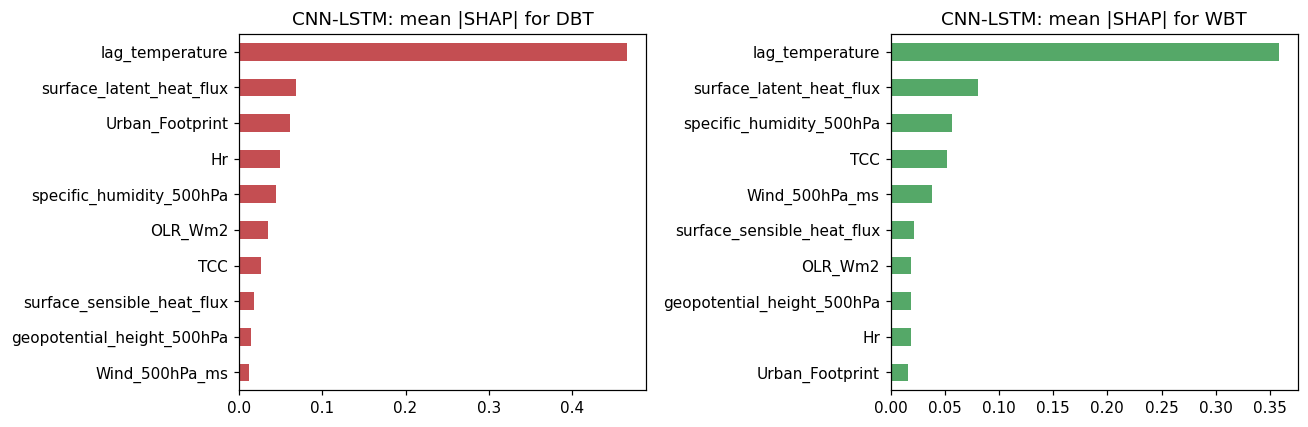

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
channel_shap_dbt.sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("CNN-LSTM: mean |SHAP| for DBT")
channel_shap_wbt.sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("CNN-LSTM: mean |SHAP| for WBT")
plt.tight_layout()
plt.show()

## Comparison against the internship's SHAP findings

Internship (report Section 3.4):
- **DBT (Ridge)**: dominated by `T(i-1)`, then `Hr`, then surface latent heat flux;
  `T(i-4)`, `T(i-2)`, `T(i-3)` also substantial; smaller contributions from specific
  humidity, OLR, geopotential height, Urban Footprint, wind, sensible heat flux.
- **WBT (LightGBM)**: dominated by `T(i-4)`, then `T(i-1)`, OLR, `T(i-2)`; surface
  sensible heat flux and `Hr` also notable; Urban Footprint moderate; smaller
  contributions from specific humidity, geopotential height, wind.

This project's CNN-LSTM collapses the 4 individual lag terms into one
`lag_temperature` channel (by construction — see notebook 02/03's sequence design),
so a term-by-term lag comparison (e.g. "does T(i-4) beat T(i-1) here too") isn't
directly reproducible from this architecture. What **is** directly comparable: does
the lag-temperature channel *as a whole* dominate over the static meteorological
channels, matching the internship's finding that temporal persistence dominates
both targets? The printed ranking above answers that directly - filled in with the
actual numbers once run, not asserted in advance.


In [7]:
print("DBT: lag_temperature rank position:",
      list(channel_shap_dbt.sort_values(ascending=False).index).index("lag_temperature") + 1,
      "of", len(channel_shap_dbt))
print("WBT: lag_temperature rank position:",
      list(channel_shap_wbt.sort_values(ascending=False).index).index("lag_temperature") + 1,
      "of", len(channel_shap_wbt))

DBT: lag_temperature rank position: 1 of 10
WBT: lag_temperature rank position: 1 of 10


In [8]:
import pickle
with open("data/processed/shap_results.pkl", "wb") as f:
    pickle.dump({"dbt": channel_shap_dbt, "wbt": channel_shap_wbt}, f)
print("Saved shap_results.pkl")

Saved shap_results.pkl
